
# Generative Adversarial Network (GAN) – Workshop Notebook

This workshop notebook focuses on **adversarial learning mechanics**.

Target audience:
- Learners familiar with neural networks
- Students comparing GAN vs VAE

You will learn:
- Minimax game intuition
- Generator vs Discriminator
- Training instability


## 1. Imports

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


## 2. Hyperparameters

In [2]:

batch_size = 128
epochs = 20
lr = 0.0002
latent_dim = 100
image_dim = 28 * 28


## 3. Dataset

In [3]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


## 4. Generator and Discriminator

In [4]:

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, image_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(image_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


## 5. Training Loop

In [5]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G, D = Generator().to(device), Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

for epoch in range(epochs):
    for real, _ in loader:
        real = real.view(-1, image_dim).to(device)
        batch = real.size(0)

        noise = torch.randn(batch, latent_dim).to(device)
        fake = G(noise)

        real_labels = torch.ones(batch, 1).to(device)
        fake_labels = torch.zeros(batch, 1).to(device)

        loss_D = criterion(D(real), real_labels) +                  criterion(D(fake.detach()), fake_labels)

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        loss_G = criterion(D(fake), real_labels)
        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")


Epoch 1 | D Loss: 0.9805 | G Loss: 0.7660
Epoch 2 | D Loss: 0.6434 | G Loss: 1.2505
Epoch 3 | D Loss: 0.7722 | G Loss: 1.2419
Epoch 4 | D Loss: 0.5755 | G Loss: 1.6068
Epoch 5 | D Loss: 0.4915 | G Loss: 1.5995
Epoch 6 | D Loss: 1.4644 | G Loss: 0.8143
Epoch 7 | D Loss: 0.8169 | G Loss: 1.3723
Epoch 8 | D Loss: 1.1020 | G Loss: 1.0531
Epoch 9 | D Loss: 1.0657 | G Loss: 1.0462
Epoch 10 | D Loss: 1.5403 | G Loss: 0.8586
Epoch 11 | D Loss: 1.0746 | G Loss: 0.9882
Epoch 12 | D Loss: 1.5826 | G Loss: 0.7813
Epoch 13 | D Loss: 1.5442 | G Loss: 0.7699
Epoch 14 | D Loss: 0.9768 | G Loss: 1.2215
Epoch 15 | D Loss: 0.5871 | G Loss: 1.7224
Epoch 16 | D Loss: 0.8100 | G Loss: 1.3697
Epoch 17 | D Loss: 1.3387 | G Loss: 0.8349
Epoch 18 | D Loss: 1.3309 | G Loss: 0.8855
Epoch 19 | D Loss: 0.9205 | G Loss: 1.2043
Epoch 20 | D Loss: 1.4191 | G Loss: 0.9713


## 6. Sample Generation

(-0.5, 27.5, 27.5, -0.5)

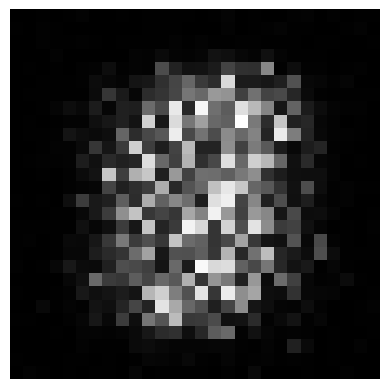

In [6]:

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = G(z).view(-1, 1, 28, 28)

samples = (samples + 1) / 2
plt.imshow(samples[0][0], cmap="gray")
plt.axis("off")


## 7. Key Takeaways
- GANs learn via competition
- Loss curves are unstable
- No explicit likelihood